Suiting the quantum representation to permutation representation

In [606]:
import numpy as np
import matplotlib.pyplot as plt
import pdb

In [5]:
m = 20
j = 20
cur_range = 3
total = 2*j

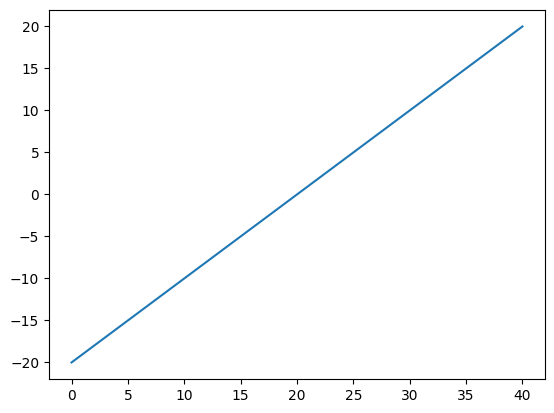

In [344]:
plt.plot(np.linspace(0, 40, 10000), np.linspace(0, 40, 10000) - 20)

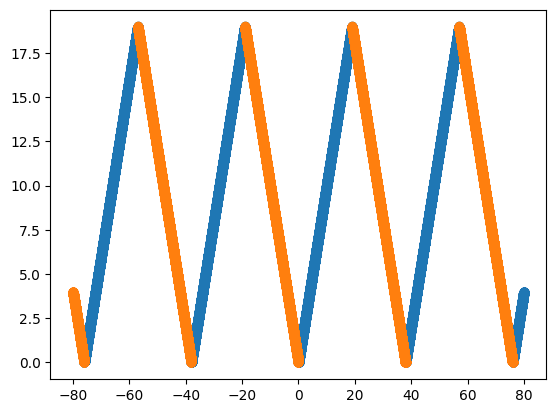

In [689]:
y = lambda x, offset, sign: sign*(x - offset)

x1_base = np.linspace(-80, 80, 100000)
x1 = x1_base[(np.floor(x1_base) // 19) % 2 == 0]
x2_base = np.linspace(-80, 80, 100000)
x2 = x2_base[(np.floor(x1_base) // 19) % 2 > 0]
Y = y(x1, (np.floor(x1) // 19)*19, 1)
Y_2 = y(x2, (np.floor(x2) // 19)*19 + 19, -1)

fig, ax = plt.subplots()
ax.scatter(x1, Y)
ax.scatter(x2, Y_2)

In [364]:
def periodic_triangular_function(x:float, j: int):
    y = lambda x, offset, sign: sign*(x - offset)
    if (np.floor(x) // j) % 2 == 0:
        # Even case -> positive slope
        cur_offset = (np.floor(x) // j)*j
        return np.round(y(x, cur_offset, 1))
    else:
        # Odd case -> negative slope
        cur_offset = (np.floor(x) // j)*j+j
        return np.round(y(x, cur_offset, -1))

def periodic_triangular_function_vectorized(x: np.ndarray, j: int) -> np.ndarray:
    y = lambda x, offset, sign: sign*(x - offset)
    y_res = np.empty_like(x)
    
    x1 = x[(np.floor(x) // j) % 2 == 0]
    x2 = x[(np.floor(x) // j) % 2 > 0]

    y_res[(np.floor(x) // j) % 2 == 0] = y(x1, (np.floor(x1) // j)*j, 1)
    y_res[(np.floor(x) // j) % 2 > 0] = y(x2, ((np.floor(x2) // j)*j)+j, -1)

    return np.floor(y_res)


In [354]:
test_list = []
cur_angle = 0.5

for i in range(10000):
    new_drawn_value = np.random.normal(0, 0.05) + cur_angle
    job_value = periodic_triangular_function(new_drawn_value, 20)
    test_list.append(job_value)

In [682]:
np.max(np.random.randint(0, 20, 10000))

19

In [706]:
class EnhancedQuantumRandomKeyIndividual:
    def __init__(self, j, m):
        self.m = m
        self.j = j
        self.start_std = j / 4
        self.base_permutation = np.repeat(np.arange(self.j), self.m)
        self.initialize_individual()
        self.create_permutation()

    def initialize_individual(self):
        self.positions = np.random.randint(0, self.j, size=self.j*self.m)
        self.standard_deviations = np.ones(shape=self.j*self.m) * self.start_std

    def periodic_triangular_function_vectorized(self, x: np.ndarray, j: int) -> np.ndarray:
        y = lambda x, offset, sign: sign*(x - offset)
        y_res = np.empty_like(x)
        
        x1 = x[(np.floor(x) // j) % 2 == 0]
        x2 = x[(np.floor(x) // j) % 2 > 0]

        y_res[(np.floor(x) // j) % 2 == 0] = y(x1, (np.floor(x1) // j)*j, 1)
        y_res[(np.floor(x) // j) % 2 > 0] = y(x2, ((np.floor(x2) // j)*j)+j, -1)

        return np.floor(y_res)

    def create_permutation(self):
        self.random_keys = self.periodic_triangular_function_vectorized(np.round(np.random.normal(0, self.standard_deviations) + self.positions).astype(int), self.j-1) 
        self.permutation = self.base_permutation[np.argsort(self.random_keys)]

    def int_rotation(self, b: object):
        # transfer all angles into interval [0, j]
        b_keys = b.random_keys
        x_keys = self.random_keys
        x_filtered = self.positions
        # Check if the two angles are within the variance
        equal_cases_overshoot = np.logical_and(b_keys == x_keys, (b_keys - x_keys) <= 0)
        equal_cases_undershoot = np.logical_and(b_keys == x_keys, (b_keys - x_keys) >= 0)
        unequal_cases_overshoot = np.logical_and(b_keys != x_keys, (b_keys - x_keys) < 0)
        unequal_cases_undershoot = np.logical_and(b_keys != x_keys, (b_keys - x_keys) > 0)

        x_filtered[equal_cases_overshoot] += 0 #np.random.uniform(0.01, 0.05)
        x_filtered[unequal_cases_overshoot] -= 1 #np.random.uniform(0.01, 0.05)
        x_filtered[equal_cases_undershoot] -= 0 #np.random.uniform(0.01, 0.05)
        x_filtered[unequal_cases_undershoot] += 1 #np.random.uniform(0.01, 0.05)
        # Contribute to std convergence
        self.standard_deviations[equal_cases_overshoot] -= 0.5
        self.standard_deviations[unequal_cases_overshoot] -= 0.1
        self.standard_deviations[equal_cases_undershoot] -= 0.5
        self.standard_deviations[unequal_cases_undershoot] -= 0.1
        self.standard_deviations[self.standard_deviations < 0] = 0
        # Handle values outside thw supported range
        self.positions = np.abs(x_filtered) % self.j


In [710]:
b = EnhancedQuantumRandomKeyIndividual(j, m)
x = EnhancedQuantumRandomKeyIndividual(j, m)

In [711]:
b.random_keys

array([11., 16., 10., 17., 17., 15.,  9., 16., 13., 16., 18.,  1.,  0.,
       12., 16., 11.,  3.,  3., 18.,  1.,  9.,  9., 12., 11., 17.,  2.,
       13.,  9.,  9., 19.,  6.,  6.,  5., 13.,  8.,  6., 13., 15.,  6.,
       14., 11., 10., 10.,  9., 17., 14., 17.,  5.,  8.,  1., 13., 18.,
       17.,  1., 18., 11.,  5.,  0., 18., 16.,  6., 10.,  2., 17.,  5.,
        5., 16.,  7.,  5., 15.,  6.,  8.,  2., 13.,  1.,  1.,  6.,  5.,
       11., 16., 12.,  8., 10., 18.,  4.,  6., 13.,  5.,  1.,  6., 11.,
       18.,  6.,  1.,  5., 18., 16., 17., 11., 17.,  8., 13., 10., 14.,
       14., 18.,  7., 14., 11.,  3., 11., 17.,  1., 16., 10., 15.,  7.,
        9., 17.,  6., 13.,  7., 10., 12.,  2., 11., 18.,  8., 18., 12.,
        8.,  7., 17., 18.,  7.,  3.,  4., 12., 15., 19.,  2.,  8.,  3.,
       14.,  6.,  7.,  8., 14., 12.,  0., 11.,  2., 14.,  4., 11., 12.,
        4., 18.,  1.,  1., 14.,  1., 15., 19., 11., 12.,  4.,  4., 12.,
        3.,  1.,  1., 16.,  4., 18., 17., 10.,  5., 11., 14.,  4

In [717]:
for i in range(10):
    x.int_rotation(b)
    x.create_permutation()
print(x.random_keys - b.random_keys)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [694]:
x.int_rotation(b)

In [695]:
x.positions[115]

15

In [696]:
b.random_keys[np.where(x.positions - b.random_keys != 0)]

array([], dtype=float64)

In [621]:
b.random_keys - x.random_keys 

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  5.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0., 15.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0

In [365]:
test_individual = np.random.randint(0, j, size=m*j)
test_individual_2 = np.random.randint(0, j, size=m*j)

test_random_keys = periodic_triangular_function_vectorized(np.round(np.random.normal(0, 0.01) + test_individual).astype(int), j)
next_permutation = np.repeat(np.arange(j), m)[np.argsort(test_random_keys.astype(int))]

test_random_keys = periodic_triangular_function_vectorized(np.round(np.random.normal(0, 0.01) + test_individual_2).astype(int), j)
next_permutation_2 = np.repeat(np.arange(j), m)[np.argsort(test_random_keys.astype(int))]

In [366]:
np.unique(next_permutation, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 array([20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
        20, 20, 20], dtype=int64))

In [368]:
def int_rotation(b: np.ndarray, x: np.ndarray, j):
    # transfer all angles into interval [0, j]
    b_filtered = np.abs(b) % j
    x_filtered = np.abs(x) % j
    # Check if the two angles are within the variance
    equality_radius = 1/(j*2)
    equal_cases_overshoot = np.logical_and(b_filtered == x_filtered, (b_filtered - x_filtered) < 0)
    equal_cases_undershoot = np.logical_and(b_filtered == x_filtered, (b_filtered - x_filtered) > 0)
    unequal_cases_overshoot = np.logical_and(b_filtered != x_filtered, (b_filtered - x_filtered) < 0)
    unequal_cases_undershoot = np.logical_and(b_filtered != x_filtered, (b_filtered - x_filtered) > 0)
    
    x_filtered[equal_cases_overshoot] += 0 #np.random.uniform(0.01, 0.05)
    x_filtered[unequal_cases_overshoot] -= 1#np.random.uniform(0.01, 0.05)
    x_filtered[equal_cases_undershoot] -= 0 #np.random.uniform(0.01, 0.05)
    x_filtered[unequal_cases_undershoot] += 1#np.random.uniform(0.01, 0.05)
    return x_filtered

In [369]:
next_permutation - next_permutation_2

array([ 12,  -2,   3,  -9,   4,  -6,  -2,  10,  -3,  -4,  -5,   6,  11,
        -2,  -3,  -1,  12,  -5,   6,   7,   5,   1,  -4,  -2, -12,   0,
       -15,  -8,   5, -12,   6,  -8,  16,   4,   2,  15,  11, -10,  -7,
        17, -16,   3,  -8, -13,   5,  -2, -15,  -5, -10,  11,  11,   3,
        -6,   0,  10, -12,   4,   3,   0, -16,   3,  15,  -6, -12,  -8,
         2,   0,   4,   8,  10,   3,  11,  10,   4,   3,  17,  -1,   3,
        -1,  16, -13,   3, -19,  10,   0,   5, -11,   1,  -7,   9,   7,
        -7,  12,   1,   1,   0,   1,   1,   6,  18,   1,   3, -11,  10,
        -2,  15,   9,   7,  -5,   4,  -5, -14, -13,   2,  11, -10,  -3,
       -10,  -9,  -3,  -4,   9,   5,   6,   2,  10,   6,  -6,  -7,  11,
        -8,  -1,   8,  -4,  -6,   0,   2,   2,   1,   9,  -8,   5,   1,
         6,  -7,  -6,   1,   3,  11,   5,   2,   2,  -1,   3,   5,   0,
         6,   0,  10,  16,   8,   5,  -3, -11,  11,  -3,  -5,  -4,   7,
         2, -15,  -4,  -3, -13,   1,  -2, -10,  -2,  -9, -11,  -

In [ ]:
for i in range(1000):
    test_individual_2 = int_rotation(test_individual, test_individual_2, j)

    test_random_keys = periodic_triangular_function_vectorized(np.round(np.random.normal(0, 0.01) + test_individual).astype(int), j)
    next_permutation = np.repeat(np.arange(j), m)[np.argsort(test_random_keys.astype(int))]

    test_random_keys_2 = periodic_triangular_function_vectorized(np.round(np.random.normal(0, 0.01) + test_individual_2).astype(int), j)
    next_permutation_2 = np.repeat(np.arange(j), m)[np.argsort(test_random_keys_2.astype(int))]

print(np.abs(test_individual - test_individual_2)[np.abs(test_individual - test_individual_2) > 0.025])
print(test_random_keys - test_random_keys_2)
#print(np.all(np.abs(test_individual - test_individual_2) <= 0.01))
print(next_permutation - next_permutation_2)

[]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [371]:
print(next_permutation - next_permutation_2)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [307]:
periodic_triangular_function_vectorized(np.round(np.random.normal(0, 0.000001) + test_individual, decimals=2), j) - periodic_triangular_function_vectorized(np.round(np.random.normal(0, 0.000001) + test_individual_2, decimals=2), j)

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0

In [249]:
test_individual[7]

0.6293440518100603

In [250]:
test_individual_2[7]

0.6233696798959174

In [257]:
np.random.normal(0, 0.000001)

9.861488980749092e-07

In [267]:
test_val = 0.6442
np.trunc(test_val*100)/100

0.64

In [295]:
np.trunc((10**2)*(test_individual))/100

array([0.27, 0.97, 0.17, 0.06, 0.36, 0.78, 0.92, 0.41, 0.75, 0.39, 0.72,
       0.82, 0.69, 0.46, 0.48, 0.48, 0.28, 0.89, 0.49, 0.75, 0.8 , 0.88,
       0.07, 0.27, 0.15, 0.81, 0.27, 0.45, 0.38, 0.22, 0.45, 0.63, 0.27,
       0.57, 0.02, 0.11, 0.49, 0.24, 0.18, 0.44, 0.71, 0.02, 0.97, 0.41,
       0.52, 0.21, 0.1 , 0.68, 0.78, 0.25, 0.06, 0.34, 0.91, 0.73, 0.59,
       0.9 , 0.21, 0.62, 0.98, 0.41, 0.46, 0.32, 0.07, 0.03, 0.14, 0.69,
       0.98, 0.89, 0.17, 0.63, 0.31, 0.36, 0.79, 0.73, 0.26, 0.31, 0.84,
       0.02, 0.4 , 0.37, 0.89, 0.76, 0.03, 0.92, 0.42, 0.35, 0.96, 0.62,
       0.43, 0.77, 0.58, 0.9 , 0.65, 0.45, 0.39, 0.42, 0.51, 0.94, 0.2 ,
       0.1 , 0.03, 0.8 , 0.4 , 0.76, 0.1 , 0.61, 0.25, 0.22, 0.74, 0.81,
       0.44, 0.39, 0.74, 0.01, 0.03, 0.37, 0.53, 0.49, 0.91, 0.1 , 0.61,
       0.62, 0.62, 0.62, 0.56, 0.83, 0.37, 0.48, 0.61, 0.99, 0.48, 0.18,
       0.91, 0.76, 0.56, 0.83, 0.41, 0.85, 0.13, 0.53, 0.96, 0.68, 0.21,
       0.14, 0.7 , 0.67, 0.2 , 0.38, 0.74, 0.42, 0.

In [296]:
np.trunc((10**2)*(test_individual_2))/(10**2)

array([0.27, 0.97, 0.17, 0.06, 0.37, 0.78, 0.92, 0.41, 0.74, 0.38, 0.72,
       0.81, 0.68, 0.46, 0.48, 0.49, 0.28, 0.88, 0.49, 0.75, 0.8 , 0.88,
       0.07, 0.28, 0.15, 0.8 , 0.27, 0.45, 0.38, 0.22, 0.45, 0.63, 0.27,
       0.57, 0.03, 0.11, 0.49, 0.24, 0.18, 0.44, 0.71, 0.02, 0.96, 0.41,
       0.52, 0.21, 0.1 , 0.68, 0.78, 0.25, 0.07, 0.34, 0.91, 0.73, 0.58,
       0.9 , 0.21, 0.62, 0.98, 0.42, 0.45, 0.32, 0.07, 0.03, 0.13, 0.69,
       0.98, 0.89, 0.18, 0.63, 0.31, 0.37, 0.79, 0.73, 0.26, 0.31, 0.84,
       0.03, 0.4 , 0.37, 0.89, 0.75, 0.03, 0.91, 0.41, 0.35, 0.96, 0.62,
       0.43, 0.77, 0.58, 0.89, 0.65, 0.45, 0.39, 0.42, 0.51, 0.94, 0.21,
       0.1 , 0.03, 0.79, 0.4 , 0.76, 0.1 , 0.61, 0.25, 0.22, 0.74, 0.8 ,
       0.43, 0.4 , 0.73, 0.01, 0.04, 0.37, 0.53, 0.5 , 0.9 , 0.1 , 0.62,
       0.63, 0.62, 0.62, 0.55, 0.83, 0.37, 0.47, 0.61, 0.99, 0.48, 0.18,
       0.91, 0.75, 0.56, 0.84, 0.41, 0.86, 0.13, 0.53, 0.96, 0.68, 0.22,
       0.14, 0.7 , 0.68, 0.21, 0.38, 0.73, 0.42, 0.

In [297]:
np.trunc((10**2)*(test_individual))/(10**2) - np.trunc((10**2)*(test_individual_2))/(10**2)

array([ 0.  ,  0.  ,  0.  ,  0.  , -0.01,  0.  ,  0.  ,  0.  ,  0.01,
        0.01,  0.  ,  0.01,  0.01,  0.  ,  0.  , -0.01,  0.  ,  0.01,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.01,  0.  ,  0.01,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.01,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.01,  0.  ,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.01,  0.  ,  0.  ,  0.  ,
        0.01,  0.  ,  0.  ,  0.  ,  0.  , -0.01,  0.01,  0.  ,  0.  ,
        0.  ,  0.01,  0.  ,  0.  ,  0.  , -0.01,  0.  ,  0.  , -0.01,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.01,  0.  ,  0.  ,  0.  ,
        0.01,  0.  ,  0.01,  0.01,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.  ,  0.01,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.01,
        0.  ,  0.  ,  0.01,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.  ,  0.01,  0.01, -0.01,  0.01,  0.  , -0.01,  0.  ,  0.  ,
       -0.01,  0.01,  0.  , -0.01, -0.01,  0.  ,  0.  ,  0.01,  0.  ,
        0.  ,  0.01,

In [375]:
np.random.normal(0, np.array([1,2,3]))

array([ 0.26003539, -1.21968856, -2.69546027])